# V1 Runned JEPA-PPO Failure Analysis

Executed Kaggle notebook retained as the V1 baseline/failure record.


## V1 Failure Analysis

This run is kept as evidence for why V2 is needed. The data pipeline ran correctly, with 31 assets, 29 features, and chronological train/val/test datasets.

Key observations:

- JEPA learned a latent representation, but the final validation loss (`~0.0495`) was much higher than the final training loss (`~0.0110`). This indicates limited generalization.
- The supervised market heads failed to generalize: final train loss was around `7.13`, while validation loss was around `106.53`.
- PPO diverged: rollout loss, reward and equity became `NaN`.
- Backtest metrics are invalid because equity/returns/costs contain `NaN` or `inf` values.
- The printed randomization-test interpretation is therefore not valid. A positive interpretation must never be emitted when metrics are non-finite.

Conclusion: V1 is an inconclusive/failed baseline, not a successful strategy. It motivates V2: a unified JEPA world model with VICReg anti-collapse regularization, action-conditioned portfolio outcome imagination, and planner-first decision making.


In [1]:
# Run this cell on Kaggle if the repo is not already available.
import os
import sys
from pathlib import Path

REPO = Path("/kaggle/working/jepa-for-trading")

if not REPO.exists():
    !git clone -b version1 https://github.com/aurvl/jepa-for-trading.git {REPO}

%cd /kaggle/working/jepa-for-trading

# Important on Kaggle: install with the current notebook Python and avoid CUDA/RAPIDS dependency churn.
!{sys.executable} -m pip install -q -e . --no-deps

# Safety: editable installs can be invisible until kernel refresh; force src on sys.path.
SRC = str(REPO / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import jepa_trading
print("jepa_trading loaded from:", jepa_trading.__file__)


Cloning into '/kaggle/working/jepa-for-trading'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 74 (delta 9), reused 72 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 422.45 KiB | 5.15 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/kaggle/working/jepa-for-trading
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jepa-trading (pyproject.toml) ... done
jepa_trading loaded from: /kaggle/working/jepa-for-trading/src/jepa_trading/__init__.py


In [2]:
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from jepa_trading.config import ensure_dirs, load_config
from jepa_trading.data.pipeline import prepare_market_data, create_jepa_dataloaders
from jepa_trading.models.jepa import MarketJEPA
from jepa_trading.models.heads import MarketHeads
from jepa_trading.models.policy import PortfolioPolicy
from jepa_trading.rl.observer import JEPAMarketObserver
from jepa_trading.rl.env import TradingEnv
from jepa_trading.rl.ppo import PPOConfig, train_ppo
from jepa_trading.training.train_jepa import train_jepa
from jepa_trading.training.train_heads import train_market_heads
from jepa_trading.training.checkpoints import load_checkpoint, save_checkpoint
from jepa_trading.evaluation.backtest import (
    run_policy_backtest,
    run_weight_strategy,
    buy_and_hold_weight,
    equal_weight,
    momentum_weight,
    volatility_target_weight,
    random_long_only_weight,
)
from jepa_trading.evaluation.metrics import metrics_table
from jepa_trading.evaluation.plots import plot_equity_curves, plot_drawdown, plot_turnover
from jepa_trading.evaluation.statistical_tests import randomization_p_value, bootstrap_mean_return_p_value
from jepa_trading.utils.device import get_device
from jepa_trading.utils.seed import seed_everything

In [3]:
config = load_config('configs/default.yaml')

# Kaggle input discovery.
# Priority:
# 1) macro_data.parquet if you upload it directly;
# 2) estimated_volatility_with_macro.csv from your Kaggle dataset;
# 3) any CSV containing "macro" in its name.
macro_candidates = []
if Path('/kaggle/input').exists():
    macro_candidates.extend(Path('/kaggle/input').rglob('macro_data.parquet'))
    macro_candidates.extend(Path('/kaggle/input').rglob('estimated_volatility_with_macro.csv'))
    macro_candidates.extend(Path('/kaggle/input').rglob('*macro*.csv'))

# Your current Kaggle dataset path, kept explicit for clarity.
explicit_macro_csv = Path('/kaggle/input/datasets/aurelvehi/estimated-volatility-with-macro/estimated_volatility_with_macro.csv')
if explicit_macro_csv.exists():
    macro_candidates.insert(0, explicit_macro_csv)

if macro_candidates:
    config['data']['macro_path'] = str(macro_candidates[0])
else:
    print('WARNING: no macro file found under /kaggle/input. Current path:', config['data']['macro_path'])

print('Macro file used:', config['data']['macro_path'])

# Toggle for debugging. Full run uses the YAML values.
FAST_DEV_RUN = False
if FAST_DEV_RUN:
    config['data']['tickers'] = config['data']['tickers'][:8]
    config['training']['jepa_max_steps'] = 20
    config['training']['heads_max_steps'] = 20
    config['training']['eval_every'] = 10
    config['ppo']['total_updates'] = 2
    config['ppo']['rollout_steps'] = 32

ensure_dirs(config)
seed_everything(config['seed'])
device = get_device(config['device'])
device


Macro file used: /kaggle/input/datasets/aurelvehi/estimated-volatility-with-macro/estimated_volatility_with_macro.csv


device(type='cuda')

In [4]:
prepared_df, arrays, feature_columns = prepare_market_data(config, force_download=False)
loaders = create_jepa_dataloaders(config, arrays)

print('rows:', len(prepared_df))
print('dates:', arrays.dates.min(), '->', arrays.dates.max())
print('assets:', len(arrays.tickers), arrays.tickers)
print('features:', len(feature_columns), feature_columns)
print('dataset sizes:', {k: len(v.dataset) for k, v in loaders.items()})

rows: 165325
dates: 2005-01-03 00:00:00 -> 2026-06-10 00:00:00
assets: 31 ['AAPL', 'AMZN', 'BA', 'BAC', 'CAT', 'COST', 'CVX', 'GE', 'GLD', 'GOOGL', 'HD', 'IWM', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'QQQ', 'SPY', 'TLT', 'UNH', 'WMT', 'XLE', 'XLF', 'XLI', 'XLK', 'XLV', 'XOM']
features: 29 ['log_return', 'overnight_gap', 'intraday_range', 'volume_z', 'rsi_scaled', 'macd', 'rolling_vol_21', 'rolling_vol_63', 'sigma_log', 't1_growth_pulse__raw_factor', 't2_macro_repricing__raw_factor', 't3_inflation_pressure__raw_factor', 't4_financial_stress__raw_factor', 't5_technical_pressure__raw_factor', 't1_growth_pulse__score', 't2_macro_repricing__score', 't3_inflation_pressure__score', 't4_financial_stress__score', 't5_technical_pressure__score', 'theme_growth_raw_factor', 'theme_fx_rates_raw_factor', 'theme_inflation_commodity_raw_factor', 'theme_stress_raw_factor', 'theme_technical_pressure_raw_factor', 'theme_growth_score', 'theme_fx_rates_score', 'theme_inflation_commodity_s

In [5]:
jepa = MarketJEPA(
    n_features=len(feature_columns),
    max_assets=len(arrays.tickers),
    **config['model'],
    ema_decay=config['training']['ema_decay'],
)
jepa_ckpt = Path(config['training']['checkpoint_dir']) / 'market_jepa.pt'

if jepa_ckpt.exists():
    print('Loading JEPA checkpoint:', jepa_ckpt)
    load_checkpoint(jepa_ckpt, jepa, map_location=device)
    jepa_history = pd.DataFrame()
else:
    jepa_history = train_jepa(
        jepa,
        loaders['train'],
        loaders['val'],
        device,
        max_steps=config['training']['jepa_max_steps'],
        lr=config['training']['lr'],
        weight_decay=config['training']['weight_decay'],
        checkpoint_path=jepa_ckpt,
        eval_every=config['training']['eval_every'],
        log_every=config['training']['log_every'],
    )
    load_checkpoint(jepa_ckpt, jepa, map_location=device)
jepa_history.tail()

/kaggle/working/jepa-for-trading/src/jepa_trading/models/encoders.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)


train JEPA:   0%|          | 0/2000 [00:00<?, ?it/s]

,step,train_loss,val_loss
1995,1996,0.011150,NaN
1996,1997,0.011609,NaN
1997,1998,0.011078,NaN
1998,1999,0.011040,NaN
1999,2000,0.010976,0.049507


In [6]:
heads = MarketHeads(latent_dim=config['model']['latent_dim'])
heads_ckpt = Path(config['training']['checkpoint_dir']) / 'market_heads.pt'

if heads_ckpt.exists():
    print('Loading heads checkpoint:', heads_ckpt)
    load_checkpoint(heads_ckpt, heads, map_location=device)
    heads_history = pd.DataFrame()
else:
    heads_history = train_market_heads(
        jepa,
        heads,
        loaders['train'],
        loaders['val'],
        device,
        max_steps=config['training']['heads_max_steps'],
        lr=config['training']['lr'],
        checkpoint_path=heads_ckpt,
        eval_every=config['training']['eval_every'],
    )
    load_checkpoint(heads_ckpt, heads, map_location=device)
heads_history.tail()

train heads:   0%|          | 0/1000 [00:00<?, ?it/s]

,step,loss,return_quantile_loss,sigma_loss,drawdown_loss,positive_loss,val_loss
995,996,8.794316,1.003895,0.016503,15.218641,0.691395,NaN
996,997,12.043820,1.314101,0.015431,21.098392,0.691232,NaN
997,998,9.653397,1.104376,0.029539,16.723497,0.690010,NaN
998,999,8.440645,1.005872,0.015190,14.508801,0.691110,NaN
999,1000,7.132689,0.950014,0.009190,12.012083,0.688153,106.532082


In [7]:
observer = JEPAMarketObserver(
    arrays=arrays,
    jepa=jepa,
    heads=heads,
    lookback=config['data']['lookback'],
    horizons=config['data']['horizons'],
    device=device,
)

train_env = TradingEnv(
    arrays,
    observer,
    start_date=pd.Timestamp(config['data']['train_end']) - pd.DateOffset(years=3),
    end_date=pd.Timestamp(config['data']['val_end']),
    lookback=config['data']['lookback'],
    cash_initial=config['portfolio']['cash_initial'],
    transaction_cost_bps=config['portfolio']['transaction_cost_bps'],
    max_weight_per_asset=config['portfolio']['max_weight_per_asset'],
    max_turnover=config['portfolio']['max_turnover'],
    drawdown_penalty=config['ppo']['reward_drawdown_penalty'],
    turnover_penalty=config['ppo']['reward_turnover_penalty'],
    concentration_penalty=config['ppo']['reward_concentration_penalty'],
)
obs0, mask0 = train_env.reset()
policy = PortfolioPolicy(
    obs_dim=len(obs0),
    n_assets=len(arrays.tickers),
    max_weight=config['portfolio']['max_weight_per_asset'],
)
ppo_cfg = PPOConfig(**{k: config['ppo'][k] for k in PPOConfig.__dataclass_fields__.keys()})
policy_ckpt = Path(config['training']['checkpoint_dir']) / 'ppo_policy.pt'

if policy_ckpt.exists():
    print('Loading PPO policy:', policy_ckpt)
    load_checkpoint(policy_ckpt, policy, map_location=device)
    ppo_history = pd.DataFrame()
else:
    ppo_history = train_ppo(train_env, policy, ppo_cfg, device)
    save_checkpoint(policy_ckpt, policy, kind='ppo_policy')
ppo_history.tail()

train PPO:   0%|          | 0/50 [00:00<?, ?it/s]

,update,loss,rollout_reward_mean,rollout_reward_sum,equity
45,46,NaN,NaN,NaN,NaN
46,47,NaN,NaN,NaN,NaN
47,48,NaN,NaN,NaN,NaN
48,49,NaN,NaN,NaN,NaN
49,50,NaN,NaN,NaN,NaN


In [8]:
test_start = pd.Timestamp(config['data']['val_end']) + pd.Timedelta(days=1)
test_end = arrays.dates.max()

def make_test_env():
    return TradingEnv(
        arrays,
        observer,
        start_date=test_start,
        end_date=test_end,
        lookback=config['data']['lookback'],
        cash_initial=config['portfolio']['cash_initial'],
        transaction_cost_bps=config['portfolio']['transaction_cost_bps'],
        max_weight_per_asset=config['portfolio']['max_weight_per_asset'],
        max_turnover=config['portfolio']['max_turnover'],
        drawdown_penalty=config['ppo']['reward_drawdown_penalty'],
        turnover_penalty=config['ppo']['reward_turnover_penalty'],
        concentration_penalty=config['ppo']['reward_concentration_penalty'],
    )

agent_hist = run_policy_backtest(make_test_env(), policy, device)
bh_hist = run_weight_strategy(make_test_env(), buy_and_hold_weight)
equal_hist = run_weight_strategy(make_test_env(), equal_weight)
mom_hist = run_weight_strategy(make_test_env(), momentum_weight)
vol_hist = run_weight_strategy(make_test_env(), volatility_target_weight)

rng = np.random.default_rng(config['seed'])
random_hists = [
    run_weight_strategy(make_test_env(), lambda env, mask, rng=rng: random_long_only_weight(env, mask, rng))
    for _ in range(100)
]

histories = {
    'JEPA-PPO Agent': agent_hist,
    'Buy & Hold': bh_hist,
    'Equal Weight': equal_hist,
    'Momentum': mom_hist,
    'Vol Target': vol_hist,
}
metrics_table(histories)

/kaggle/working/jepa-for-trading/src/jepa_trading/rl/env.py:111: RuntimeWarning: overflow encountered in scalar multiply
  next_equity = investable * gross
/kaggle/working/jepa-for-trading/src/jepa_trading/rl/env.py:113: RuntimeWarning: invalid value encountered in scalar divide
  drawdown = next_equity / max(self.state.peak_equity, 1e-8) - 1.0
/kaggle/working/jepa-for-trading/src/jepa_trading/rl/env.py:68: RuntimeWarning: invalid value encountered in scalar divide
  drawdown = self.state.equity / max(self.state.peak_equity, 1e-8) - 1.0
/kaggle/working/jepa-for-trading/src/jepa_trading/evaluation/metrics.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = equity.pct_change().fillna(0.0)
/kaggle/working/jepa-for-trading/src/jepa_trading/evaluation/metrics.py:11: FutureWarning: The

,model,total_return,cagr,annualized_vol,sharpe,sortino,max_drawdown,hit_rate,avg_turnover,total_cost,avg_cash_weight
0,JEPA-PPO Agent,NaN,NaN,0.0,0.0,NaN,NaN,0.000000,NaN,0.000000e+00,NaN
1,Buy & Hold,NaN,NaN,NaN,NaN,inf,-0.247637,0.237209,0.000465,2.000000e-01,0.800000
2,Equal Weight,NaN,NaN,NaN,NaN,inf,-0.816893,0.083721,0.002326,8.708908e+00,0.002326
3,Momentum,NaN,NaN,NaN,NaN,inf,-0.893783,0.073256,0.247645,3.414408e+34,0.265444
4,Vol Target,NaN,NaN,NaN,NaN,inf,-0.766073,0.089535,0.040298,inf,0.002326


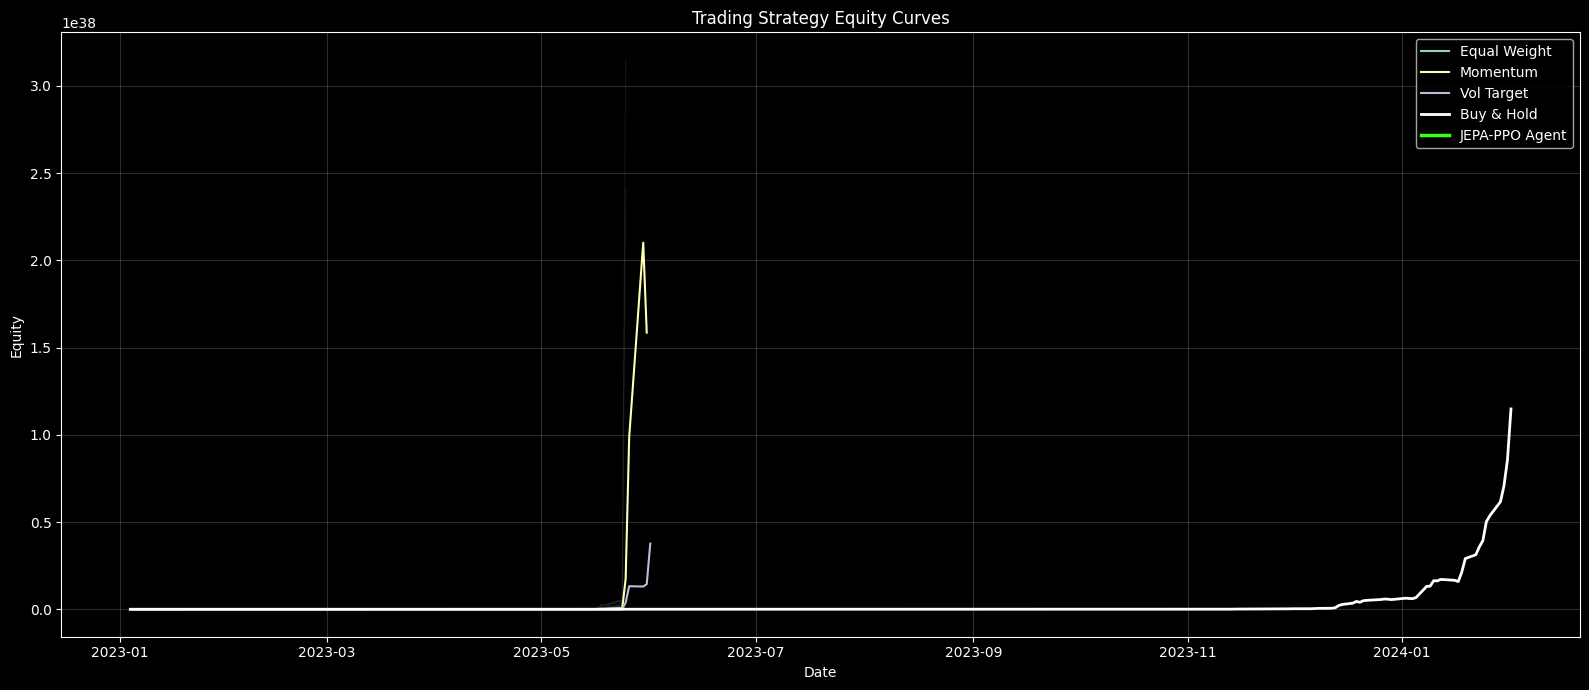

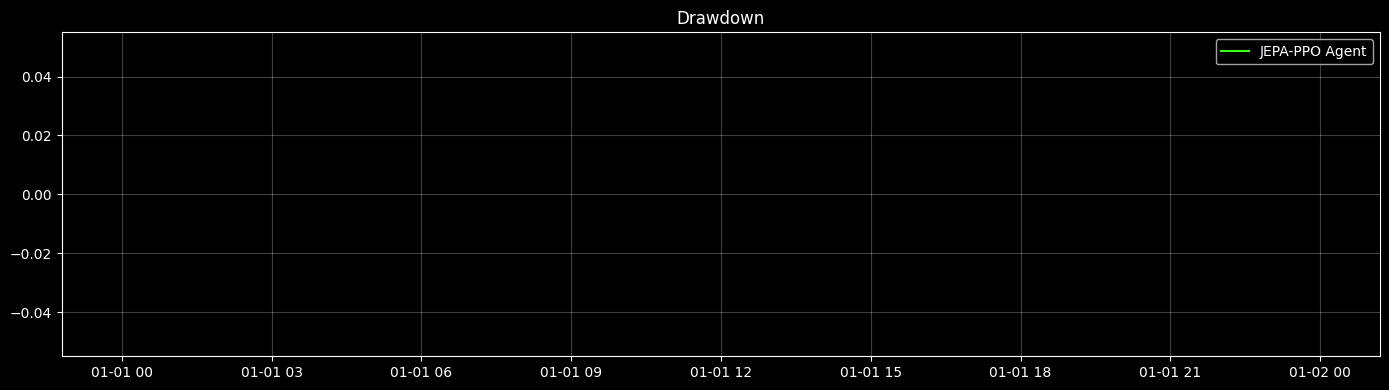

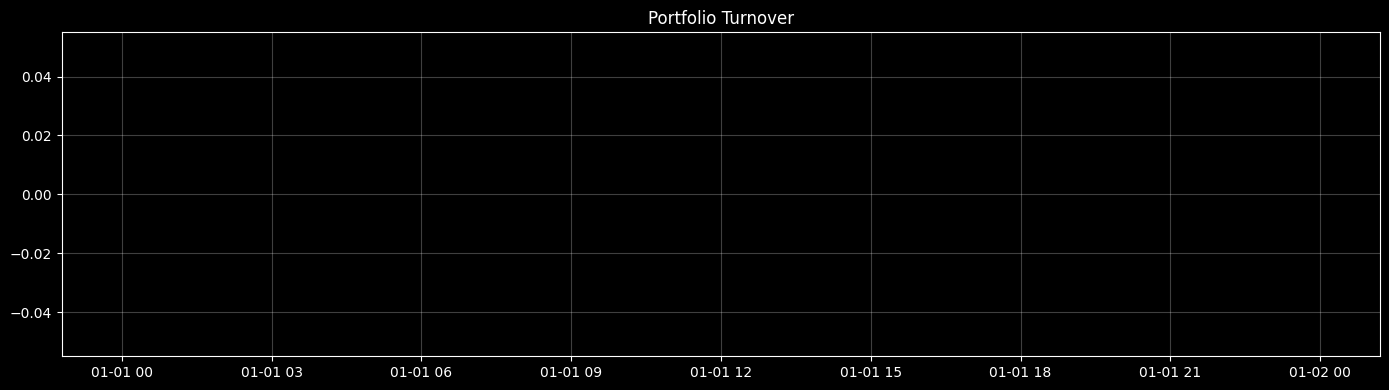

In [9]:
plot_equity_curves(
    agent_hist,
    bh_hist,
    random_hists,
    extra={'Equal Weight': equal_hist, 'Momentum': mom_hist, 'Vol Target': vol_hist},
)
plot_drawdown(agent_hist)
plot_turnover(agent_hist)

In [10]:
rand_test = randomization_p_value(agent_hist, random_hists)
boot_test = bootstrap_mean_return_p_value(agent_hist, bh_hist)
print('Randomization test:', rand_test)
print('Bootstrap vs Buy & Hold:', boot_test)

if rand_test['p_value_random_beats_agent'] < 0.05:
    print('Interpretation: agent beats random strategies with strong empirical significance.')
elif rand_test['p_value_random_beats_agent'] < 0.20:
    print('Interpretation: agent is above most random strategies, but evidence is moderate.')
else:
    print('Interpretation: agent may still be close to random. Inspect reward, costs, splits, and overfitting.')

Randomization test: {'agent_total_return': nan, 'random_mean_total_return': nan, 'random_best_total_return': nan, 'p_value_random_beats_agent': 0.0}
Bootstrap vs Buy & Hold: {'mean_daily_excess_return': nan, 'bootstrap_p_value_leq_zero': 0.0}
Interpretation: agent beats random strategies with strong empirical significance.


/kaggle/working/jepa-for-trading/src/jepa_trading/evaluation/statistical_tests.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  agent = agent_history["equity"].pct_change().dropna().to_numpy()
/kaggle/working/jepa-for-trading/src/jepa_trading/evaluation/statistical_tests.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bench = benchmark_history["equity"].pct_change().dropna().to_numpy()
/kaggle/working/jepa-for-trading/src/jepa_trading/evaluation/statistical_tests.py:29: RuntimeWarning: Mean of empty slice
  observed = diff.mean()
/usr/local/lib/python3.12/dist-packages/numpy/_core/_meth

## Push Kaggle Outputs Back To GitHub

Use this after training if you want to push notebooks, logs, checkpoints, and outputs from Kaggle back to the `version1` branch.

Recommended: create a Kaggle Secret named `GITHUB_TOKEN` containing a GitHub personal access token with access to `aurvl/jepa-for-trading`.

This cell uses `git add .` as requested. Git LFS is enabled when available so large `.pt/.pth/.ckpt/.parquet/.csv` artifacts can be tracked cleanly. Be careful: pushing very large model/data artifacts to GitHub can be slow and may hit storage quotas.


In [15]:
import os
import subprocess
import getpass
from pathlib import Path

REPO = Path('/kaggle/working/jepa-for-trading')
os.chdir(REPO)

GIT_USER_NAME = 'aurvl'
GIT_USER_EMAIL = 'aurelvehi@outlook.fr'
COMMIT_MESSAGE = 'Finishing training version1'
BRANCH = 'version1'
REMOTE_URL_SAFE = 'https://github.com/aurvl/jepa-for-trading.git'


def run(cmd, check=True, capture=False):
    print('$', ' '.join(cmd))
    return subprocess.run(cmd, check=check, text=True, capture_output=capture)

run(['git', 'config', 'user.name', GIT_USER_NAME])
run(['git', 'config', 'user.email', GIT_USER_EMAIL])

# Git LFS is optional on Kaggle. If available, use it for checkpoints and data artifacts.
lfs_check = subprocess.run(['git', 'lfs', 'version'], text=True, capture_output=True)
if lfs_check.returncode == 0:
    run(['git', 'lfs', 'install'])
    run(['git', 'lfs', 'track', '*.pt', '*.pth', '*.ckpt', '*.parquet', '*.csv'])
else:
    print('git-lfs is not available in this Kaggle image; continuing without LFS.')

# Prefer Kaggle Secret GITHUB_TOKEN. Fallback to hidden prompt.
token = os.environ.get('GITHUB_TOKEN')
if token is None:
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret('GITHUB_TOKEN')
    except Exception:
        token = None
if not token:
    token = getpass.getpass('GitHub token (input hidden): ')

if not token:
    raise RuntimeError('No GitHub token provided. Add Kaggle Secret GITHUB_TOKEN or paste a token in the prompt.')

auth_remote = f'https://github.com/aurvl/jepa-for-trading.git'
run(['git', 'remote', 'set-url', 'origin', auth_remote])

# Add tracked/unignored files first, then force-add generated artifacts that are ignored by default.
run(['git', 'add', '.'])
for artifact_dir in ['models', 'outputs', 'logs', 'data/processed', 'data/cache', 'data/interim']:
    if Path(artifact_dir).exists():
        run(['git', 'add', '-f', artifact_dir])
status = run(['git', 'status', '--short'], capture=True)
print(status.stdout)

commit = subprocess.run(['git', 'commit', '-m', COMMIT_MESSAGE], text=True, capture_output=True)
print(commit.stdout)
if commit.returncode != 0:
    print(commit.stderr)
    print('Nothing to commit or commit failed. Continuing to push current HEAD.')

run(['git', 'push', 'origin', f'HEAD:{BRANCH}'])

# Remove token from stored remote URL after push.
run(['git', 'remote', 'set-url', 'origin', REMOTE_URL_SAFE])
print('Pushed to:', REMOTE_URL_SAFE, 'branch:', BRANCH)


$ git config user.name aurvl
$ git config user.email aurelvehi@outlook.fr
$ git lfs install
Updated git hooks.
Git LFS initialized.
$ git lfs track *.pt *.pth *.ckpt *.parquet *.csv
"*.pt" already supported
"*.pth" already supported
"*.ckpt" already supported
"*.parquet" already supported
"*.csv" already supported


GitHub token (input hidden):  ········


$ git remote set-url origin https://github.com/aurvl/jepa-for-trading.git
$ git add .
$ git add -f models
$ git add -f outputs
$ git add -f logs
$ git add -f data/processed
$ git add -f data/cache
$ git add -f data/interim
$ git status --short

On branch version1
Your branch is ahead of 'origin/version1' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


Nothing to commit or commit failed. Continuing to push current HEAD.
$ git push origin HEAD:version1
Uploading LFS objects: 100% (4/4), 24 MB | 0 B/s, done.
$ git remote set-url origin https://github.com/aurvl/jepa-for-trading.git
Pushed to: https://github.com/aurvl/jepa-for-trading.git branch: version1


To https://github.com/aurvl/jepa-for-trading.git
   693272e..4369a26  HEAD -> version1
